<center> B3093 - MATHEMATICAL AND MACHINE LEARNING METHODS IN IMAGING

Second cycle degree (LM) in Mathematics -- A.Y. 2023-2024

Lab 2 - Exercise 2
<center>

The following lines install and set some packages needed for data visualization.

In [ ]:
!apt-get update
!apt-get install -y xvfb
!apt-get install -y libgl1-mesa-glx
!pip install pyvista -qq
!pip install plyfile

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,383 kB]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [2,788 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,833 kB]
Hit:13 https://ppa.launchpadco

In [ ]:
import pyvista as pv
import numpy as np
import tensorflow as tf
import plyfile
import skimage.measure
import time

In [ ]:
pv.set_jupyter_backend('static')
pv.global_theme.notebook = True
pv.start_xvfb()

# Data loading

The following lines load the input data.

In [ ]:
pointcloud_path = "/content/stanford_bunny_2.5kv_pc.xyz"

print("Loading point cloud")
point_cloud = np.genfromtxt(pointcloud_path)
print("Finished loading point cloud")

pc_coords = point_cloud[:, :3]
pc_normals = point_cloud[:, 3:]

Loading point cloud
Finished loading point cloud


# Point cloud visualization

The following lines prepare the data in the format needed by the package PyVista for the visualization. <br>
In the print, you can see the number of points of the point cloud, given by the parameter `N Points`.

In [ ]:
point_cloud = pv.PolyData(pc_coords)
point_cloud

PolyData,Information
N Cells,2503
N Points,2503
N Strips,0
X Bounds,"-9.438e-02, 6.078e-02"
Y Bounds,"-5.872e-02, 6.168e-02"
Z Bounds,"3.464e-02, 1.870e-01"
N Arrays,0


/usr/local/lib/python3.11/dist-packages/pyvista/jupyter/notebook.py:37: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


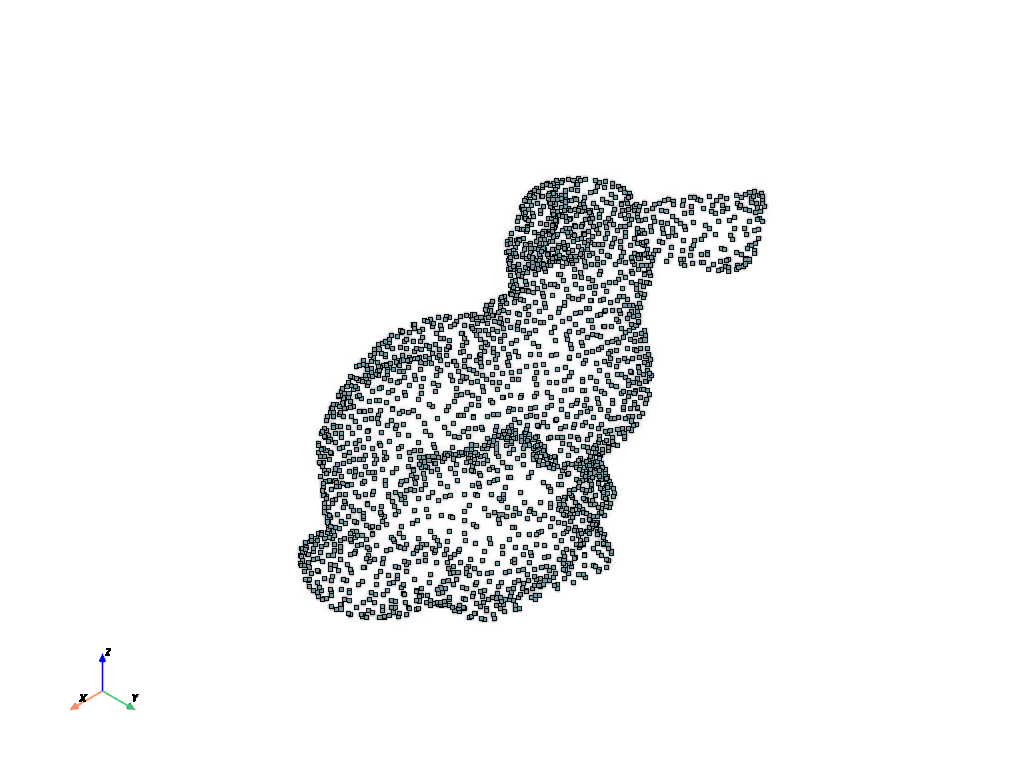

In [ ]:
point_cloud.plot(eye_dome_lighting=True, jupyter_backend='html')

The following lines associate the points with the normal vectors and visualize them.

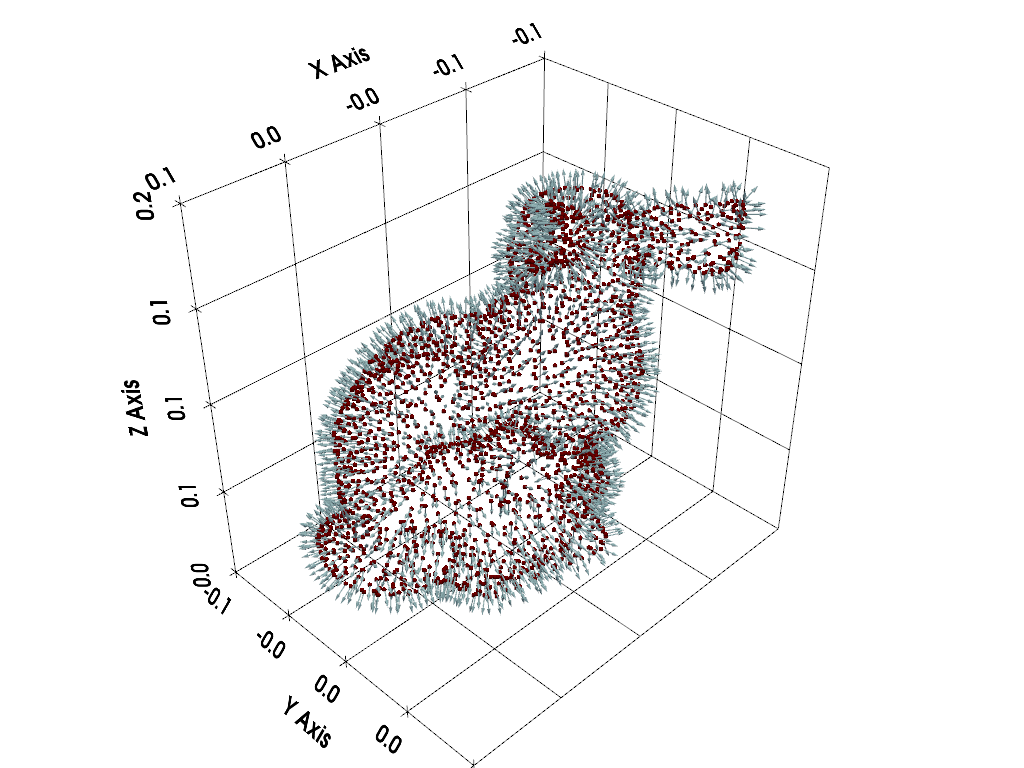

In [ ]:
point_cloud['normals'] = pc_normals

arrows = point_cloud.glyph(
    orient='normals',
    scale=False,
    factor=0.0075,
)

# Display the arrows
plotter = pv.Plotter()
plotter.add_mesh(point_cloud, color='maroon', point_size=5.0, render_points_as_spheres=True)
plotter.add_mesh(arrows, color='lightblue')
plotter.show_grid()
plotter.show()

# TF Dataset preparation

The following lines implement a function to rescale the input coordinates in the volume $[0,1]^3 \in \mathbb{R}^3$

In [ ]:
def rescale_coords(coords):

  # Reshape point cloud such that it lies in bounding box of (-1, 1) (distorts geometry, but makes for high
  # sample efficiency)
  coords -= np.mean(coords, axis=0, keepdims=True)
  coord_max = np.amax(coords)
  coord_min = np.amin(coords)
  coords = (coords - coord_min) / (coord_max - coord_min)
  coords -= 0.5
  coords *= 2.

  return coords

The following lines implement a function to prepare the dataset in the format needed by Tensorflow.

In [ ]:
def prepare_dataset(coords, normals, batch_size):

  on_surface_points = batch_size

  point_cloud_size = coords.shape[0]

  # get total number of samples based on the batchsize
  off_surface_samples = on_surface_points
  total_samples = on_surface_points + off_surface_samples

  # Random idxs for coords/normals of on-surface points
  rand_idcs = np.random.choice(point_cloud_size, size=on_surface_points)
  on_surface_coords = coords[rand_idcs, :]
  on_surface_normals = normals[rand_idcs, :]

  # Random coords for on-surface points -- normals
  off_surface_coords = np.random.uniform(-1, 1, size=(off_surface_samples, 3))
  off_surface_normals = np.ones((off_surface_samples, 3)) * -1

  # set the signed dinstance function
  sdf = np.zeros((total_samples, 1))  # on-surface = 0
  sdf[on_surface_points:, :] = -1  # off-surface = -1

  coords = np.concatenate((on_surface_coords, off_surface_coords), axis=0)
  normals = np.concatenate((on_surface_normals, off_surface_normals), axis=0)

  x_train = np.concatenate((coords,normals), axis=1)

  y_train = sdf

  train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(total_samples)

  return train_dataset.batch(total_samples)

# TODO -- Instantiate a SIREN network

By reading the [paper about SIREN](https://arxiv.org/abs/2006.09661), focusing in particular on Sec. 3.1, 3.2 and 4.2 along with Sec. 1.5 and 4 from its appendix, you have to implement the SIREN network. <br>
Pay attention to:
  - How do they define the initialization strategies for the weights?
  - Is there any implementation consideration about the initialization strategies for the first layer and for the hidden layers?
  - And the same about the activation function?
  - How many hidden layers does their implemented network have?
  - What about the last layer? Does it have any specific activation function?

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np

omega_0 = 30

#def generate_uniform_input(num_samples, input_dim):
    #return np.random.uniform(low=-1, high=1, size=(num_samples, input_dim))   # 1/512 dovrebbe funzionare;

def uniform_1_weight_initializer(shape, dtype=None):
    fan_in = shape[0]
    limit  = tf.sqrt(9 / fan_in) / omega_0;
    return tf.random.uniform(shape, minval=-limit, maxval=limit, dtype=dtype)

def uniform_2_weight_initializer(shape, dtype=None):
    fan_in = shape[0]
    limit  = tf.sqrt(6 / fan_in) / omega_0;
    return tf.random.uniform(shape, minval=-limit, maxval=limit, dtype=dtype)

def my_sine(x, omega_0=30):
    return tf.sin(omega_0 * x)

class SineDense(layers.Layer):
    def __init__(self,units, omega_0 = 30,is_first = False,**kwargs):
        super().__init__(**kwargs)
        #self.hidden_features    = hidden_features
        self.omega_0  = omega_0
        #self.in_features = in_features
        self.units = units
        self.is_first = is_first

    def build(self,input_shape):
      if self.is_first:
        self.kernel = self.add_weight(name =  "kernel", shape = (input_shape[-1],self.units),
                                      initializer = uniform_1_weight_initializer, trainable = True )

        self.bias   = self.add_weight(name = "bias", shape=(self.units,), initializer='zeros', trainable=True)

      else:
        self.kernel = self.add_weight( name = "kernel", shape=(input_shape[-1], self.units),
                                      initializer=uniform_2_weight_initializer, trainable = True )

        self.bias   = self.add_weight(name = "bias", shape=(self.units,), initializer='zeros', trainable=True)

    def call(self, inputs):
      z = tf.matmul(inputs,self.kernel) + self.bias
      return my_sine(z, self.omega_0)

# Define model parameters
#num_samples     = 1000
input_dim       = 3     # Because we are working with volumes;
#hidden_units    = 32
#hidden_layers   = 3

# Generate input data
#x = generate_uniform_input(num_samples, input_dim)

# Define model architecture
inputs = layers.Input(shape=(input_dim,))
x      = inputs;

x =  SineDense(32,omega_0 = omega_0 ,is_first = True)(x)
x = SineDense(32,omega_0 = omega_0,is_first = False)(x)
#x = SineDense(64,omega_0 = omega_0,is_first = False)(x)
x = SineDense(32,omega_0 = omega_0,is_first = False)(x)
x = SineDense(32,omega_0 = omega_0,is_first = False)(x)
x = SineDense(32,omega_0 = omega_0,is_first = False)(x)


outputs = layers.Dense(1,activation = "linear",kernel_initializer = uniform_2_weight_initializer )(x)  #kernel_initializer = uniform_2_weight_initializer)(x)

# Create the model
model = tf.keras.Model(inputs=inputs, outputs=outputs)


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 3)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sine_dense (SineDense)               │ (None, 32)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sine_dense_1 (SineDense)             │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sine_dense_2 (SineDense)             │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sine_dense_3 (SineDense)             │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sine_dense_4 (SineDense)             │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

# Loss function

The following lines implement the loss function from the paper, for the task *4.2 Representing Shapes with Signed Distance Functions*.

In [ ]:
def sdf_loss(gt_normals, grads, gt_sdf, pred_sdf):
  '''
      x: batch of input coordinates
      y: usually the output of the trial_soln function
  '''

  # Wherever boundary_values is not equal to zero, we interpret it as a boundary constraint.
  sdf_constraint    = tf.cast(tf.where(gt_sdf != -1, pred_sdf, tf.zeros_like(pred_sdf)), dtype=tf.float64)
  inter_constraint  = tf.cast(tf.where(gt_sdf != -1, tf.zeros_like(pred_sdf), tf.math.exp(-1e2 * tf.abs(pred_sdf))), dtype=tf.float64)
  normal_constraint = tf.where(gt_sdf != -1, 1 - tf.keras.losses.cosine_similarity(grads, gt_normals, axis=-1)[..., tf.newaxis], tf.zeros_like(grads[..., :1]))
  grad_constraint   = tf.abs(tf.norm(grads, axis=1) - 1)

  sdf               = tf.reduce_mean( tf.abs(sdf_constraint)) * 3e3
  inter             = tf.reduce_mean( inter_constraint) * 1e2
  normal_constraint = tf.reduce_mean( normal_constraint) * 1e2  # 1e2)
  grad_constraint   = tf.reduce_mean( grad_constraint) * 5e1  # 1e1      # 5e1)

  return sdf + inter + normal_constraint + grad_constraint

# Optimizer

The following line instantiate an Adam optimizer, with the learning rate they have used in the paper.

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

# Instantiate the dataset

The following lines executes the functions needed for the creation of the dataset. Note that the batch size cannot be larger than the number of points, as for the implementation of the function `prepare_dataset`.

In [ ]:
batch_size=2000
scaled_coords = rescale_coords(pc_coords)
train_dataset = prepare_dataset(scaled_coords, pc_normals, batch_size)

# the following lines to explore the dataset
for element in train_dataset.as_numpy_iterator():
  print(element[0].shape, element[1].shape)
  break

for step, (x_batch_train, y_batch_train) in enumerate(train_dataset):
  print(step)
  print(x_batch_train.shape)
  print(y_batch_train.shape)
  break


(4000, 6) (4000, 1)
0
(4000, 6)
(4000, 1)


# Training loop

The following lines implement a training loop from scratch, compared to the out-of-the-box training loop of the method `model.fit` seen in the guided laboratory exercise.
For more details about writing training loop from scratch, have a look [here](https://www.tensorflow.org/guide/keras/writing_a_training_loop_from_scratch).

In [ ]:
epochs = 5000
for epoch in range(epochs):

    # Iterate over the batches of the dataset.
    for step, (x_batch_train, y_batch_train) in enumerate(train_dataset):

        coords = tf.cast(x_batch_train[:, :3], dtype=tf.float64)
        normals = tf.cast(x_batch_train[:, 3:], dtype=tf.float64)
        gt_sdf = tf.cast(y_batch_train, dtype=tf.float64)

        # Open a GradientTape to record the operations run
        # during the forward pass, which enables auto-differentiation.
        with tf.GradientTape() as tape1:
            # Run the forward pass of the layer.
            # The operations that the layer applies
            # to its inputs are going to be recorded
            # on the GradientTape and later used to retrieve gradients of the
            # loss function with respect to its trainable parameters/weights.

            # The following Gradient Tape is instantiated in order
            # to retrieve the gradients of the loss function with respect
            # to the inputs of the network (different from its parameters).
            with tf.GradientTape() as tape2:
              tape2.watch(coords)

              pred_sdf = model(coords, training=True)

              grads_x = tape2.gradient(pred_sdf, coords)

              # Compute the loss value for this minibatch.
              loss_value = sdf_loss(normals, grads_x, gt_sdf, pred_sdf)

        # Use the gradient tape tape1 to automatically retrieve
        # the gradients of the loss with respect to the weights.
        grads = tape1.gradient(loss_value, model.trainable_weights)

        # Run one step of gradient descent by updating
        # the value of the variables to minimize the loss.
        grads, norm = tf.clip_by_global_norm(grads, 1.0)
        optimizer.apply_gradients(zip(grads, model.trainable_weights))

        # Log every 200 batches.
        if epoch % 10 == 0:
            print("Training loss (for one batch) at epoch %d: %.4f"
                % (epoch, float(loss_value))
            )


Training loss (for one batch) at epoch 0: 137.2041
Training loss (for one batch) at epoch 10: 86.3361
Training loss (for one batch) at epoch 20: 77.3883
Training loss (for one batch) at epoch 30: 69.7653
Training loss (for one batch) at epoch 40: 65.1679
Training loss (for one batch) at epoch 50: 62.4455
Training loss (for one batch) at epoch 60: 58.9450
Training loss (for one batch) at epoch 70: 56.5332
Training loss (for one batch) at epoch 80: 54.9811
Training loss (for one batch) at epoch 90: 52.4496
Training loss (for one batch) at epoch 100: 52.3203
Training loss (for one batch) at epoch 110: 49.6640
Training loss (for one batch) at epoch 120: 47.5810
Training loss (for one batch) at epoch 130: 46.2452
Training loss (for one batch) at epoch 140: 46.8069
Training loss (for one batch) at epoch 150: 46.3353
Training loss (for one batch) at epoch 160: 44.6008
Training loss (for one batch) at epoch 170: 45.2791
Training loss (for one batch) at epoch 180: 42.7933
Training loss (for one

# Model evaluation and result visualization

The following lines implement a function to evaluate the network on the points of a 3D regular grid in the volume $[0,1]^3$ in order to predict the value of the signed dinstance function for those points. <br>

The output will be the 3D numpy array of the predicted values of the signed dinstance function of the surface.

In [ ]:
def evaluate_model(
    model, filename, N=256, max_batch=64 ** 3, offset=None, scale=None
):
    start = time.time()
    ply_filename = filename

    # NOTE: the voxel_origin is actually the (bottom, left, down) corner, not the middle
    voxel_origin = [-1, -1, -1]
    voxel_size = 2.0 / (N - 1)

    overall_index = np.arange(0, N ** 3, 1, dtype=np.int64)
    samples = np.zeros((N ** 3, 4))

    # transform first 3 columns
    # to be the x, y, z index
    samples[:, 2] = overall_index % N
    samples[:, 1] = (overall_index // N) % N
    samples[:, 0] = ((overall_index // N) // N) % N

    # transform first 3 columns
    # to be the x, y, z coordinate
    samples[:, 0] = (samples[:, 0] * voxel_size) + voxel_origin[2]
    samples[:, 1] = (samples[:, 1] * voxel_size) + voxel_origin[1]
    samples[:, 2] = (samples[:, 2] * voxel_size) + voxel_origin[0]

    num_samples = N ** 3

    head = 0

    while head < num_samples:
        sample_subset = tf.constant(samples[head : min(head + max_batch, num_samples), 0:3])

        samples[head : min(head + max_batch, num_samples), 3] = tf.squeeze(model(sample_subset, training=False)).numpy().astype(np.float64)
        head += max_batch

    sdf_values = samples[:, 3]
    sdf_values = sdf_values.reshape(N, N, N)

    end = time.time()
    print("sampling takes: %f" % (end - start))

    return sdf_values



In the following lines, you call the previous function passing as input the trained model to be evaluated on a 3D regular grid of the given resolution. Increasing the grid resolution takes more time for the model evaluation.

In [ ]:
grid_resolution = 256

out = evaluate_model( model, "filename", N=grid_resolution, max_batch=64 ** 3, offset=None, scale=None )

sampling takes: 2.532927


The following lines implement the function that will extract the 3D surface as 0-level set of the signed dinstance function values, predicted by the network.

In [ ]:
def convert_sdf_samples_to_ply(
    tf_3d_sdf_tensor,
    voxel_grid_origin,
    voxel_size,
    ply_filename_out,
    offset=None,
    scale=None,
):
    """
    Convert sdf samples to .ply

    :param pytorch_3d_sdf_tensor: a numpy.ndarray of shape (n,n,n)
    :voxel_grid_origin: a list of three floats: the bottom, left, down origin of the voxel grid
    :voxel_size: float, the size of the voxels
    :ply_filename_out: string, path of the filename to save to

    This function adapted from: https://github.com/RobotLocomotion/spartan
    """

    start_time = time.time()

    numpy_3d_sdf_tensor = tf_3d_sdf_tensor
    verts, faces, normals, values = skimage.measure.marching_cubes(
            numpy_3d_sdf_tensor, level=0.0, spacing=[voxel_size] * 3
        )

    # marching_cubes returns faces as an array of shape (n_faces, 3)
    # where each row represents a triangle and contains the indices of the vertices forming the triangle.
    # PyVista's PolyData expects faces to be a 1D array where each group of 4 values represents a cell:
    # [n_points_in_face0, vertex_index0, vertex_index1, vertex_index2, n_points_in_face1, vertex_index3, ...]
    # So, we need to convert the faces array to this format.

    faces_pv = np.empty(faces.shape[0] * 4, dtype=faces.dtype)  # Pre-allocate for efficiency
    faces_pv[::4] = 3  # Number of points in each face (triangle)
    faces_pv[1::4] = faces[:, 0]
    faces_pv[2::4] = faces[:, 1]
    faces_pv[3::4] = faces[:, 2]


    # transform from voxel coordinates to camera coordinates
    # note x and y are flipped in the output of marching_cubes
    mesh_points = np.zeros_like(verts)
    mesh_points[:, 0] = voxel_grid_origin[0] + verts[:, 0]
    mesh_points[:, 1] = voxel_grid_origin[1] + verts[:, 1]
    mesh_points[:, 2] = voxel_grid_origin[2] + verts[:, 2]

    # apply additional offset and scale
    if scale is not None:
        mesh_points = mesh_points / scale
    if offset is not None:
        mesh_points = mesh_points - offset

    # try writing to the ply file

    # num_verts = verts.shape[0] # This line is not used
    # num_faces = faces.shape[0] # This line is not used

    verts_tuple = np.zeros((verts.shape[0],), dtype=[("x", "f4"), ("y", "f4"), ("z", "f4")])

    for i in range(0, verts.shape[0]):
        verts_tuple[i] = tuple(mesh_points[i, :])

    # faces_building = [] # This loop is replaced with the faces_pv creation above
    # for i in range(0, num_faces):
    #     faces_building.append(((faces[i, :].tolist(),)))
    # faces_tuple = np.array(faces_building, dtype=[("vertex_indices", "i4", (3,))])

    el_verts = plyfile.PlyElement.describe(verts_tuple, "vertex")
    #el_faces = plyfile.PlyElement.describe(faces_tuple, "face") # Replace with PyVista compatible faces

    #ply_data = plyfile.PlyData([el_verts, el_faces]) # Replace with PyVista compatible faces
    #ply_data.write(ply_filename_out) # Replace with PyVista compatible faces
    surf = pv.PolyData(mesh_points, faces_pv) # Use faces_pv instead of faces
    surf.save(ply_filename_out)  # Save the mesh to a PLY file

    return surf

In [ ]:
rec_3d_surface = convert_sdf_samples_to_ply( out, [-1, -1, -1], 2.0 / (grid_resolution - 1), "/content/test.ply", None, None, )

In the following lines, you can see a recap of the properties of the 3D surface extracted.

In [ ]:
print(rec_3d_surface)

PolyData (0x7ce06faa3640)
  N Cells:    717226
  N Points:   360075
  N Strips:   0
  X Bounds:   -1.000e+00, 1.000e+00
  Y Bounds:   -1.000e+00, 1.000e+00
  Z Bounds:   -1.000e+00, 1.000e+00
  N Arrays:   2


In the following lines, the visualization of the reconstructed 3D surface.

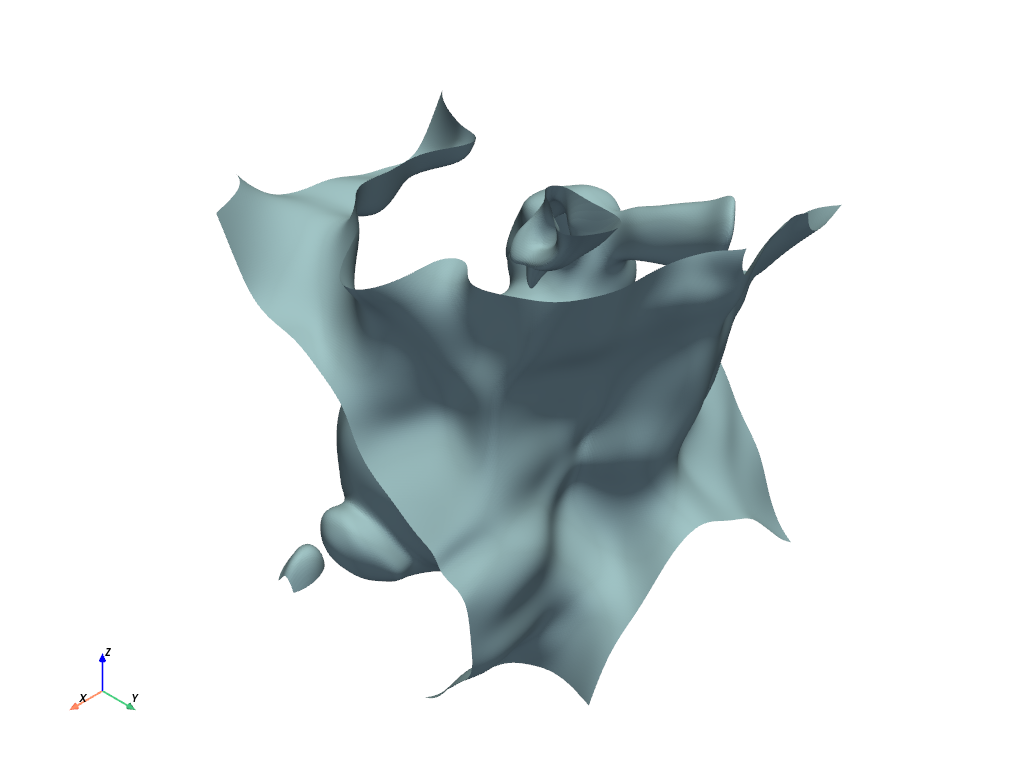

In [ ]:
pv_rec_3d_surface = pv.read("/content/test.ply")
cpos = pv_rec_3d_surface.plot()

The following lines will compute the Haussdorf distance between the reconstructed surface and the original one. Note that higher the resolution of the grid from which the surface has been extracted lower will be Hausdorff distance.

In [ ]:
original_mesh = pv.read("/content/stanford_bunny_2.5kv_surface.ply")

closest_cells, closest_points = original_mesh.find_closest_cell(pv_rec_3d_surface.points, return_closest_point=True)
d_exact = np.linalg.norm(pv_rec_3d_surface.points - closest_points, axis=1)
print(f'The Hausdorff distance is: {np.max(d_exact)}')

The Hausdorff distance is: 1.7002921290585085
